In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import GroupShuffleSplit


import sys
sys.path.append("../..")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

In [21]:
from neural_network import BasicRNN, DataFrameDataset, ToTensor, NeuralNetwork
import random
hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")

Using cpu device


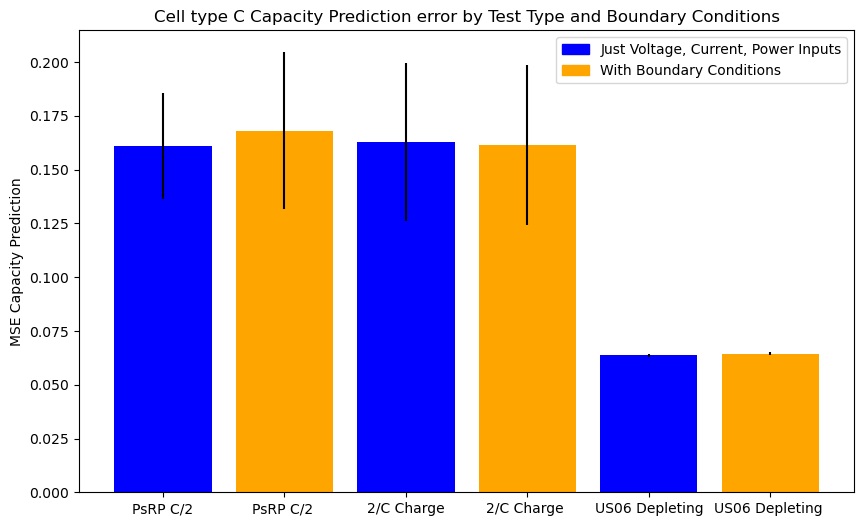

In [ ]:
psrp = [0.1181,	0.1675,	0.175,	0.154,	0.1913]
rate_test = [0.1931, 0.1734, 0.1986, 0.1527, 0.0966]
# charge_sustaining = [0.0816, 0.0745, 0.0946, 0.076, 0.0749]
charge_depleting = [0.0632, 0.0637, 0.0632, 0.0648, 0.0636]

psrp_boundary_conditions = [0.156,	0.1029,	0.1821,	0.1951,	0.2045]
rate_test_boundary_conditions = [0.189,	0.1781,	0.1978,	0.1462,	0.0962]
# charge_sustaining_boundary_conditions = [0.0816, 0.0745, 0.0946, 0.076, 0.0749]
charge_depleting_boundary_conditions = [0.064, 0.0634, 0.0644, 0.0645, 0.0658]




mean_psrp = sum(psrp) / len(psrp)
mean_rate_test = sum(rate_test) / len(rate_test)
# mean_charge_sustaining = sum(charge_sustaining) / len(charge_sustaining)
mean_charge_depleting = sum(charge_depleting) / len(charge_depleting)
mean_psrp_bc = sum(psrp_boundary_conditions) / len(psrp_boundary_conditions)
mean_rate_test_bc = sum(rate_test_boundary_conditions) / len(rate_test_boundary_conditions)
# mean_charge_sustaining_bc = sum(charge_sustaining_boundary_conditions) / len(charge_sustaining_boundary_conditions)
mean_charge_depleting_bc = sum(charge_depleting_boundary_conditions) / len(charge_depleting_boundary_conditions)

error_psrp = np.std(psrp)
error_rate_test = np.std(rate_test)
# error_charge_sustaining = np.std(charge_sustaining)
error_charge_depleting = np.std(charge_depleting)
error_psrp_bc = np.std(psrp_boundary_conditions)
error_rate_test_bc = np.std(rate_test_boundary_conditions)
# error_charge_sustaining_bc = np.std(charge_sustaining_boundary_conditions)
error_charge_depleting_bc = np.std(charge_depleting_boundary_conditions)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(['PsRP C/2', 'PsRP C/2 ','2/C Charge', '2/C Charge ', 'US06 Depleting', 'US06 Depleting '], 
       [mean_psrp, mean_psrp_bc, mean_rate_test,  mean_rate_test_bc, mean_charge_depleting, mean_charge_depleting_bc],
       yerr=[error_psrp, error_psrp_bc, error_rate_test, error_rate_test_bc, error_charge_depleting, error_charge_depleting_bc],
       color=['blue', 'orange', 'blue', 'orange', 'blue', 'orange'],)
    #    alpha=[0.7, 0.7, 0.4, 0.4])

ax.set_ylabel("MSE Capacity Prediction")
ax.set_title("Cell type C Capacity Prediction error by Test Type and Boundary Conditions")
plt.legend(handles = [blue, label="Just Voltage, Current, Power Inputs", orange, label="With Boundary Conditions"], loc='upper right')
# ax.plot(psrp, label="PsRP C/2")
# ax.plot(rate_test, label="Rate Test 1C")
# ax.plot(psrp_boundary_conditions, label="PsRP C/2 BC", linestyle='--')
# ax.plot(rate_test_boundary_conditions, label="Rate Test 1C BC", linestyle='--')

Text(0.5, 1.0, 'RNN vs XGBoost Capacity Prediction error by Test Type')

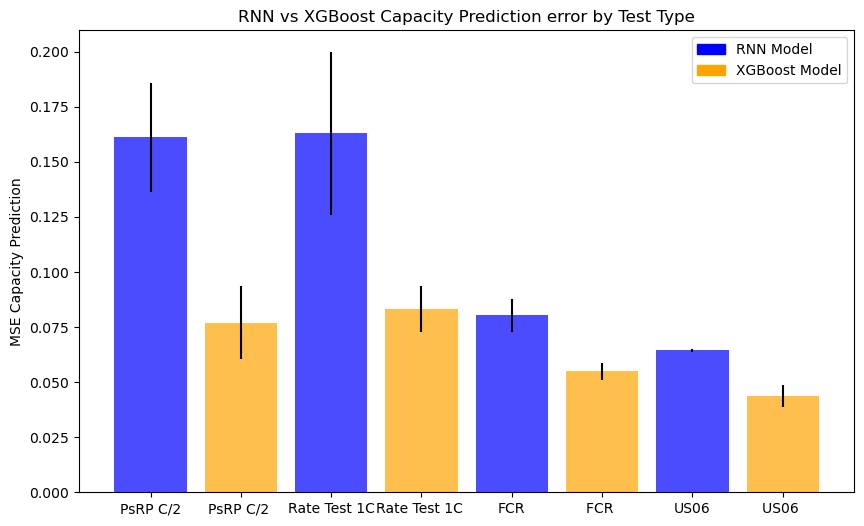

In [46]:
rnn_psrp = [0.1181, 0.1675, 0.175, 0.154, 0.1913]
rnn_rate_test = [0.1931, 0.1734, 0.1986, 0.1527, 0.0966]
rnn_charge_sustaining = [0.0816, 0.0745, 0.0946, 0.076, 0.0749]
rnn_charge_depleting = [0.064, 0.0634, 0.0644, 0.0645, 0.0658]

xgboost_psrp = [0.0556, 0.06227, 0.07594, 0.0926, 0.0989]
xgboost_rate_test = [0.08104, 0.084847, 0.071118, 0.07708, 0.101624]
xgboost_charge_sustaining = [0.0542, 0.06207, 0.05062, 0.05508, 0.05312]
xgboost_charge_depleting = [0.05114, 0.03858, 0.0479, 0.04019, 0.04082]

mean_rnn_psrp = sum(rnn_psrp) / len(rnn_psrp)
mean_rnn_rate_test = sum(rnn_rate_test) / len(rnn_rate_test)
mean_rnn_charge_sustaining = sum(rnn_charge_sustaining) / len(rnn_charge_sustaining)
mean_rnn_charge_depleting = sum(rnn_charge_depleting) / len(rnn_charge_depleting)

mean_xgboost_psrp = sum(xgboost_psrp) / len(xgboost_psrp)
mean_xgboost_rate_test = sum(xgboost_rate_test) / len(xgboost_rate_test)
mean_xgboost_charge_sustaining = sum(xgboost_charge_sustaining) / len(xgboost_charge_sustaining)
mean_xgboost_charge_depleting = sum(xgboost_charge_depleting) / len(xgboost_charge_depleting)

error_rnn_psrp = np.std(rnn_psrp)
error_rnn_rate_test = np.std(rnn_rate_test)
error_rnn_charge_sustaining = np.std(rnn_charge_sustaining)
error_rnn_charge_depleting = np.std(rnn_charge_depleting)

error_xgboost_psrp = np.std(xgboost_psrp)
error_xgboost_rate_test = np.std(xgboost_rate_test)
error_xgboost_charge_sustaining = np.std(xgboost_charge_sustaining)
error_xgboost_charge_depleting = np.std(xgboost_charge_depleting)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(['PsRP C/2', 'PsRP C/2 ', 'Rate Test 1C', 'Rate Test 1C ', 'FCR', 'FCR ', 'US06', 'US06 '], 
       [mean_rnn_psrp, mean_xgboost_psrp, mean_rnn_rate_test, mean_xgboost_rate_test, mean_rnn_charge_sustaining, mean_xgboost_charge_sustaining, mean_rnn_charge_depleting, mean_xgboost_charge_depleting],
       yerr=[error_rnn_psrp, error_xgboost_psrp, error_rnn_rate_test, error_xgboost_rate_test, error_rnn_charge_sustaining, error_xgboost_charge_sustaining, error_rnn_charge_depleting, error_xgboost_charge_depleting],
       color=['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange'], alpha=0.7)
ax.set_ylabel("MSE Capacity Prediction")
blue_patch = Patch(color='blue', label='RNN Model')
orange_patch = Patch(color='orange', label='XGBoost Model')
plt.legend(handles=[blue_patch, orange_patch], loc='upper right')
ax.set_title("RNN vs XGBoost Capacity Prediction error by Test Type")

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    # ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)
def get_metrics_all_targets(results_dict_list):
    """
    Construct a wide format df for plotting convenience
    """
    iterations = 5
    metrics = {
                'r2': [],
                'mae': [],
                'mape': [],
                'Target': [],
                'Cell ID': [],
                'Pulse Type': [],
              }
    for results_dict_soc in results_dict_list:
        for key in results_dict_soc:
            if 'features' in key:
                continue
                
            target, pulse = key.split(', ')
            if target == 'Post 1C charge relaxation fit MSE':
                continue
            df = results_dict_soc[key]
            cell_id = df['cell_id'][0][0]

            for run in range(iterations):
                test_subset = df[df[run].notna()]
                r2 = r2_score(test_subset[target], test_subset[run])
                mae = mean_absolute_error(test_subset[target], test_subset[run])
                mape = mean_absolute_percentage_error(test_subset[target], test_subset[run])         
                metrics[f"r2"].append(r2)
                metrics[f"mae"].append(mae)
                metrics["mape"].append(mape)
                
            metrics['Target'] += [target] * iterations
            metrics['Cell ID'] += [cell_id] * iterations
            metrics['Pulse Type'] += [pulse] * iterations

    return pd.DataFrame(metrics)

def t(metrics, target, pulses=None):
    metrics = metrics[metrics['Target'] == target]
    if pulses is not None:
        metrics = metrics[metrics['Pulse Type'].isin(pulses)]
    return metrics

KeyError: 'soc_mean, Charge_Depleting'

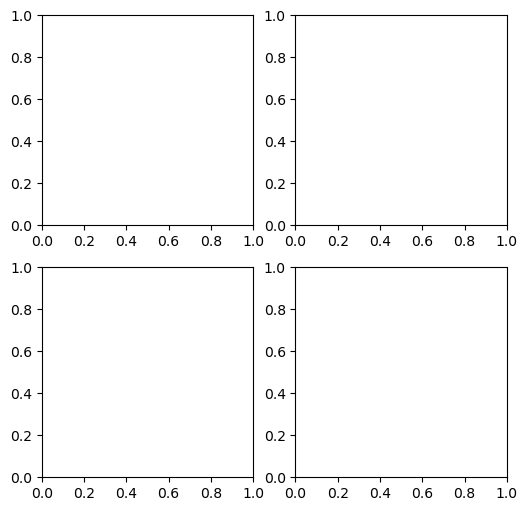

In [54]:
A = torch.load('../../results/neural_network/c_testing/bootstrap_results_A.pth', weights_only=False)
B = torch.load('../../results/neural_network/c_testing/bootstrap_results_B.pth', weights_only=False)
C = torch.load('../../results/neural_network/c_testing/bootstrap_results_C.pth', weights_only=False)
D = torch.load('../../results/neural_network/c_testing/bootstrap_results_D.pth', weights_only=False)

metrics = get_metrics_all_targets([C])

fig, ax = plt.subplots(2,2,figsize=(6, 6))
ax= ax.flatten()
# ax.set_xlabel('True Capacity (Ah)')
# ax.set_ylabel('Predicted Capacity (Ah)')
plot_true_vs_pred_axis(ax[0], 'Charge_Depleting', 'soc_mean', A, color='blue', n_splits=5, title='Cell Type A (NMC-Gr)')
plot_true_vs_pred_axis(ax[1], 'Charge_Depleting', 'soc_mean', B, color='orange', n_splits=5, title='Cell Type B (LMO-Gr)')
plot_true_vs_pred_axis(ax[2], 'Charge_Depleting', 'soc_mean', C, color='green', n_splits=5, title='Cell Type C (NMC-Gr)')
plot_true_vs_pred_axis(ax[3], 'Charge_Depleting', 'soc_mean', D, color='red', n_splits=5, title='Cell Type D (LFP-Gr)')
ax[0].set_ylabel('Predicted SOC (Ah)')
ax[2].set_ylabel('Predicted SOC (Ah)')
ax[2].set_xlabel('True SOC (Ah)')
ax[3].set_xlabel('True SOC (Ah)')

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[3].set_ylabel('')

fig.tight_layout()



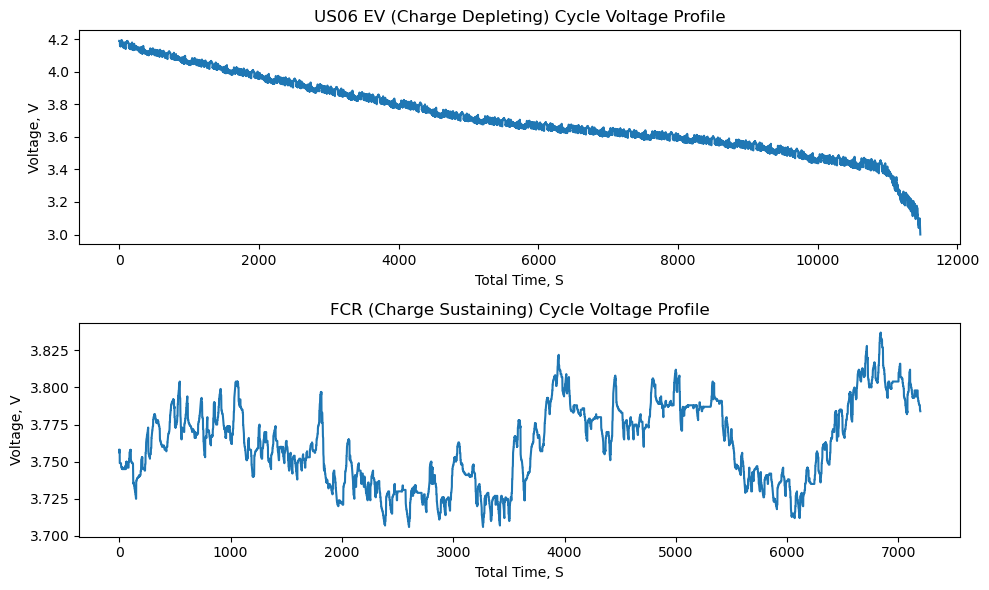

In [52]:
hdf3 = pd.HDFStore("../../data/data_raw.h5", mode="r")
keys = hdf3.keys()

df = hdf3.get(keys[-1])
segments = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
]

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

for i, segment in enumerate(segments):
    segment_df = df[df["Segment Description"] == segment].reset_index(drop=True)
    segment_df = retime(segment_df)
    ax[i].plot(segment_df["Segment Time, S"], segment_df["Voltage, V"])
    ax[i].set_title(f"Segment: {segment}")
    ax[i].set_xlabel("Total Time, S")
    ax[i].set_ylabel("Voltage, V")

ax[0].set_title("US06 EV (Charge Depleting) Cycle Voltage Profile")
ax[1].set_title("FCR (Charge Sustaining) Cycle Voltage Profile")

fig.tight_layout()

In [18]:
def get_10_min_segments(df, t_length=599):
    # t_length = 599 # for whatever reason, the sequence is 599 seconds long, not 600
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = t_length
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == t_length:
            df_segments.append(_df_segment)
        elif len(_df_segment) > t_length:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == t_length:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
        t_start += t_length
        t_end += t_length
    return df_segments

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_45992\2787770391.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 100)


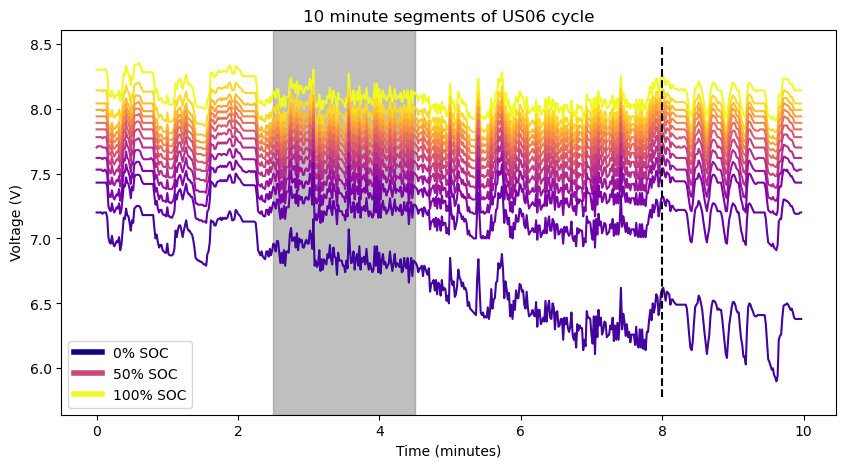

In [ ]:
hdf3 = pd.HDFStore("../../data/data_raw.h5", mode="r")
keys = hdf3.keys()

df = hdf3.get(keys[-50])
df = df[df["Segment Description"] == "Charge depleting cycle"].reset_index(drop=True)
df_segments = get_10_min_segments(df)
cmap = cm.get_cmap('plasma', 100)

fig, ax = plt.subplots(figsize=(10,5))
for segment in df_segments:
    ax.plot(segment['Segment Time, S']/60, segment['Voltage, V'], c=cmap(segment['SOC'].iloc[0]))
ax.set_title('10 minute segments of US06 cycle')

ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Voltage (V)')

ax.vlines(x=8, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='dashed', color='black')
ax.axvspan(xmin=2.5, xmax=4.5, alpha=0.5, color='gray')

plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.show()

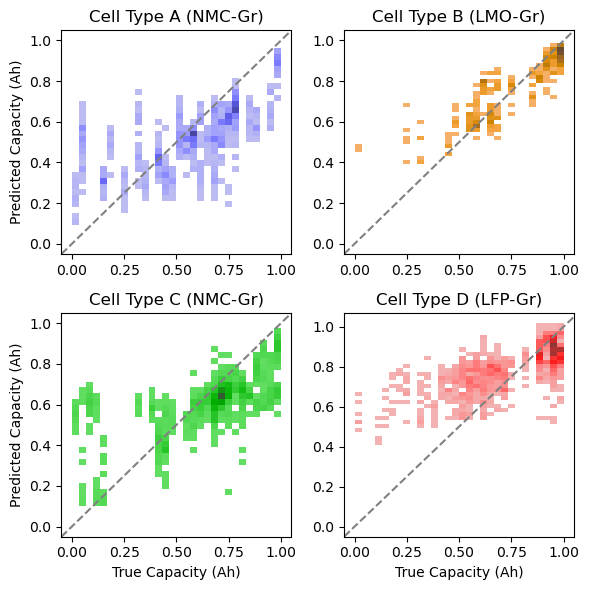

In [53]:
A = torch.load('../../results/neural_network/c_testing/bootstrap_results_A.pth', weights_only=False)
B = torch.load('../../results/neural_network/c_testing/bootstrap_results_B.pth', weights_only=False)
C = torch.load('../../results/neural_network/c_testing/bootstrap_results_C.pth', weights_only=False)
D = torch.load('../../results/neural_network/c_testing/bootstrap_results_D.pth', weights_only=False)

metrics = get_metrics_all_targets([C])

fig, ax = plt.subplots(2,2,figsize=(6, 6))
ax= ax.flatten()
# ax.set_xlabel('True Capacity (Ah)')
# ax.set_ylabel('Predicted Capacity (Ah)')
plot_true_vs_pred_axis(ax[0], 'Charge_Depleting', 'C/3 discharge capacity', A, color='blue', n_splits=5, title='Cell Type A (NMC-Gr)')
plot_true_vs_pred_axis(ax[1], 'Charge_Depleting', 'C/3 discharge capacity', B, color='orange', n_splits=5, title='Cell Type B (LMO-Gr)')
plot_true_vs_pred_axis(ax[2], 'Charge_Depleting', 'C/3 discharge capacity', C, color='green', n_splits=5, title='Cell Type C (NMC-Gr)')
plot_true_vs_pred_axis(ax[3], 'Charge_Depleting', 'C/3 discharge capacity', D, color='red', n_splits=5, title='Cell Type D (LFP-Gr)')
ax[0].set_ylabel('Predicted Capacity (Ah)')
ax[2].set_ylabel('Predicted Capacity (Ah)')
ax[2].set_xlabel('True Capacity (Ah)')
ax[3].set_xlabel('True Capacity (Ah)')

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[3].set_ylabel('')

fig.tight_layout()



C:\Users\etenney\AppData\Local\Temp\1\ipykernel_45992\2334210778.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 100)


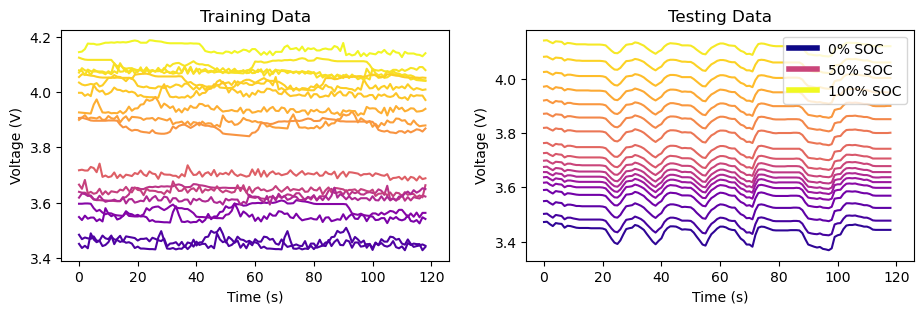

In [52]:
hdf4 = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")

df = hdf4.get("Charge_Depleting")
cmap = cm.get_cmap('plasma', 100)
df = df[df['cell_id'].str[0] == 'A']

measurement_ids = df['measurement_id'].unique()
id = measurement_ids[0]
df = df[df['measurement_id'] == id]

df_testing = df[df['split_type'] == 'testing']
df_training = df[df['split_type'] == 'training'].groupby('measurement_id').sample(frac=0.02, random_state=42).reset_index(drop=True)
fig, ax = plt.subplots(1,2,figsize=(11,3))
# df['discharge_normalized'] = df['C/3 discharge capacity'] / 65  # normalize by nominal capacity
for i, row in df_training.iterrows():
    ax[0].plot(range(121), row.filter(regex='voltage'), color=cmap(row['soc_mean']))
for i, row in df_testing.iterrows():
    ax[1].plot(range(121), row.filter(regex='voltage'), color=cmap(row['soc_mean']))

ax[0].set_title(f'Training Data')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Voltage (V)')

ax[1].set_title(f'Testing Data')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Voltage (V)')
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.show()

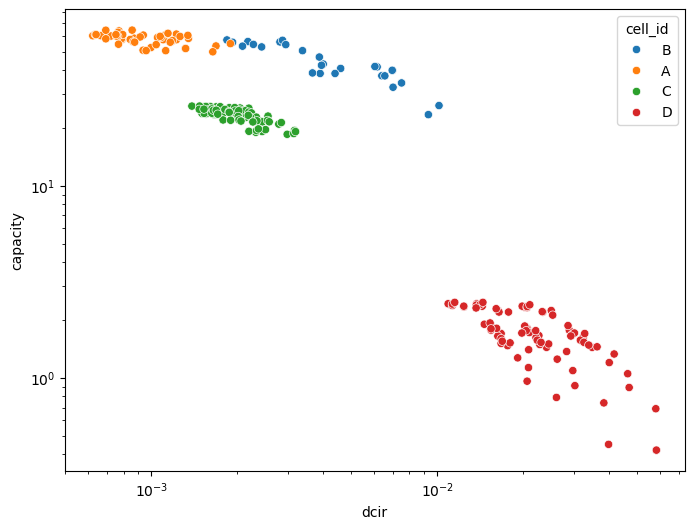

In [57]:
# hdf = pd.HDFStore('../../data/pulse_data_extracted.h5', 'r')
# keys = hdf.keys()

df_targets = pd.read_csv('../../data/targets_soh - manual volume and thickness edit.csv')
df_features = pd.read_csv('../../data/features_dcir.csv')

cell_id = df_targets['cell_id']

capacity = df_targets['C/3 discharge capacity']
dcir = (df_features['charge_resistance_10s_1C_charging'] + df_features['discharge_resistance_10s_1C_charging'])/2
temperature = df_targets['temperature_ambient']
df = pd.DataFrame({'capacity': capacity, 'dcir': dcir, 'cell_id': cell_id, 'temperature': temperature})
df.loc[df['temperature'] < 25, 'temp_category'] = '15'
df.loc[(df['temperature'] >= 25) & (df['temperature'] < 38), 'temp_category'] = '30'
df.loc[df['temperature'] >= 38, 'temp_category'] = '45'
df['cell_type'] = df['cell_id'].str[0]

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x='dcir', y='capacity', data=df, hue=df['cell_id'].str[0], ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')

for type, cap in zip(['A', 'B', 'C', 'D'], [65,66,26,2.5]):
    mask = df['cell_id'].str[0] == type
    df.loc[mask, 'capacity_normalized'] = df.loc[mask, 'capacity'] / cap


C:\Users\etenney\AppData\Local\Temp\1\ipykernel_45992\3355657351.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(df, x='capacity_normalized', col='cell_type', palette="plasma", facet_kws={'sharey': False}, col_wrap=2, height = 2, aspect=1.5, binwidth=0.05)


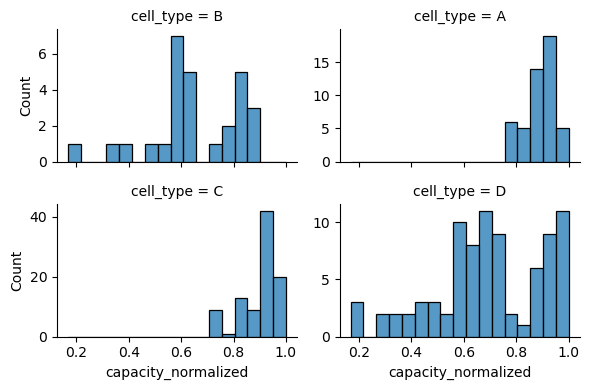

In [58]:
sns.displot(df, x='capacity_normalized', col='cell_type', palette="plasma", facet_kws={'sharey': False}, col_wrap=2, height = 2, aspect=1.5, binwidth=0.05)

Text(0, 0.5, 'Voltage, V')

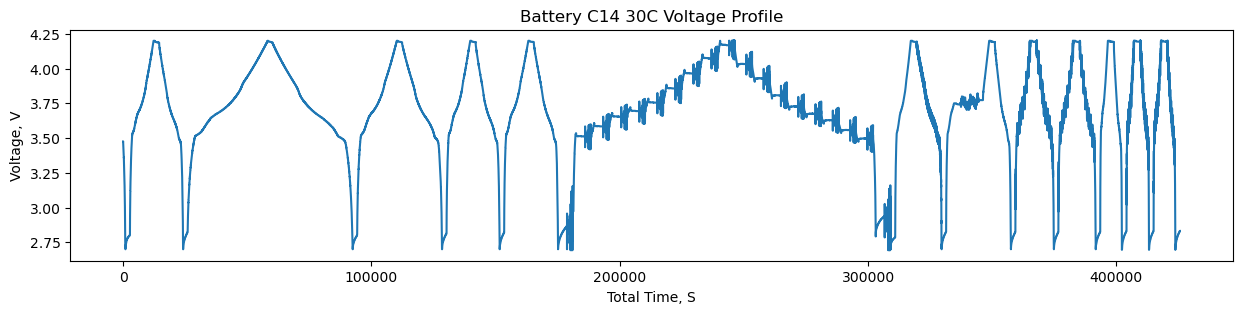

In [68]:
key = keys[100]

fig, ax = plt.subplots(figsize=(15,3))
df = hdf3.get(key)

voltage = df['Voltage, V']

ax.plot(df['Total Time, S'], voltage)
ax.set_title(f'Battery C14 30C Voltage Profile')
ax.set_xlabel('Total Time, S')
ax.set_ylabel('Voltage, V')